# Diamond Top — a quantitative teardown 🔬
### Mechanical broaden-then-narrow diamonds on 5 indices · downside-break SHORT forward returns · one-sample HAC *t* · a drift-matched random-short baseline · a shuffled-pivot geometry placebo · costs · a synthetic planted-reversal control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_a_reversal%3F: Busted](https://img.shields.io/badge/Forecasts_a_reversal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **shape** from the **drift**: an upward-trending index makes *any* short lose, so the only meaningful test is break-vs-random-short, plus a placebo that destroys the diamond's geometry while preserving its marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Pivots are confirmed fractals (k=5, an explicit 5-bar confirmation lag), diamonds over the 6 latest alternating pivots; entry is the **next close** (one documented lag); the trade is a **short**. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from diamond_top import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real diamond cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 125, 'k': 5, 'n_piv': 6, 'fp_spy': '4cb5244f3990', 'h5': (5, 124, 55.3, 50, 1.32, -18.7, 74.0, 53.3, 1.71, 0.089), 'h10': (10, 123, 20.1, 47, 0.4, -25.7, 45.7, 18.1, 0.96, 0.337), 'h20': (20, 123, -151.4, 33, -2.13, -42.9, -108.5, -153.4, -1.71, 0.088), 'h60': (60, 119, -356.6, 28, -2.78, -83.0, -273.6, -358.6, -2.55, 0.011), 'per': [('SPY', 26, -99.1, -0.52, -42.9, -56.2), ('QQQ', 19, -515.8, -5.94, -105.0, -410.8), ('IWM', 32, -237.5, -1.77, -9.7, -227.8), ('DIA', 19, -15.1, -0.13, -34.1, 19.0), ('GLD', 29, 60.8, 0.71, -22.7, 83.5)], 'placebo': (-99.1, 0.679, 500), 'syn': [(0.0, 27, 75.2, 44, 0.82), (0.6, 22, 1360.6, 77, 5.06)]}


real diamond cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Breakdown short vs a **drift-matched random-short** baseline: the short *loses more* than random at 20/60d (Δ = -108/-274 bps; 60d Welch t = -2.55, significant the WRONG way). The only positive Δ is a 5-day bounce (+74 bps) at Welch t = +1.71 (p=0.09) — never clears 2. |
| **Tradability** | `MIRAGE` | The short bleeds against drift (20d break = -151 bps, t = -2.13); no edge to scale, costs deepen the hole. |
| **Forecasts a reversal?** | `BUSTED` | Scrambling the diamond's geometry (shuffled-pivot placebo) leaves the result intact: **p = 0.68** of nonsense diamonds match or beat the real one. The shape isn't doing the work. |

> 💡 In plain words: the diamond top is sold as a *reversal* signal, but the short *loses* at the horizons that matter and loses more than a random short — the market just keeps drifting up. Strip the shape (scramble the pivots) and nothing changes. Classic pattern-shaped noise on a drifting tape.

## 1 · The claim, steelmanned

Over a run of alternating confirmed pivots with prices $y_1,\dots,y_6$, let the leg amplitudes be $a_j=|y_{j+1}-y_j|$. A **diamond** requires the $a_j$ to rise to a peak (broadening) then fall (narrowing). After the diamond completes following an advance, the rule **shorts** the first close below the narrowing-apex floor $\ell=\min(y_4,y_5,y_6)$.

- **H₀ (drift).** Break-short returns equal a drift-matched **random-short** baseline.
- **H₁ (the diamond forecasts a top).** Break-short returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the shape matters).** Break-short returns exceed a **shuffled-pivot** diamond whose geometry is nonsense.

We find **H₀ not rejected** (break ≤ random at 20/60d — in fact *worse*), **H₁ rejected** (Welch t never ≥ 2 in the right direction), **H₂ rejected** (placebo p ≈ 0.68). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. A **short** fights it; a one-sample $t$ against **zero** of a short rule manufactures a misleading *negative* number that is just the tide, not the shape. The fix is the **random-short baseline** (same instrument, epoch, hold, short sign) and a Welch test of break-*minus*-random.

**(b) Geometry as a free parameter.** A diamond is a chosen set of wiggles; the danger is that *any* broaden-then-narrow run drawn on a noisy trend gets labelled a diamond. The **shuffled-pivot placebo** keeps pivot positions and the price marginal but permutes which price sits at which pivot — the diamond shape becomes meaningless, so if the real result survives the scramble, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **125 diamond breakdowns** pooled.
- **Pivots.** Confirmed fractals: extremum with k=5 strictly-beaten bars each side; usable only at bar +5 (no look-ahead). Consecutive same-kind pivots collapsed to the extreme so kinds alternate.
- **Diamond.** Over the 6 latest confirmed pivots, leg amplitudes rise to a peak (broadening) then fall (narrowing); formed after an advance.
- **Entry.** First close below the narrowing-apex floor; **short** at the **next close** (one lag); hold H ∈ {5,10,20,60}. Trade return = −(price move).
- **Null #1 — one-sample HAC t** of break-short returns vs 0 (Newey-West).
- **Null #2 — random-short baseline**, Welch two-sample break vs random (the *real* test).
- **Null #3 — shuffled-pivot placebo** (geometry destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every break.
- **Positive control.** Synthetic tape with a **planted** diamond-top reversal (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The drift trap — one-sample t vs the honest random-short test

Left: the breakdown short's **one-sample** t against zero (misleading — for a short on a rising tape it just turns negative). Right: the same short vs a **drift-matched random-short** baseline (the honest number).

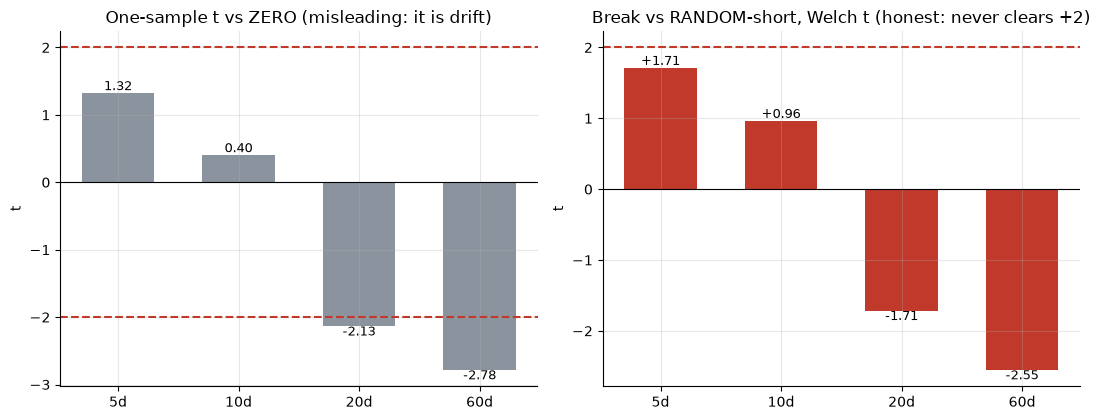

one-sample t: [1.32, 0.4, -2.13, -2.78]
welch vs random: [np.float64(1.71), np.float64(0.96), np.float64(-1.71), np.float64(-2.55)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, brk, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.diamond_breakdowns(c, k=R['k'], n_piv=R['n_piv'])
            re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); brk.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    brk = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED); a1.axhline(-2, ls='--', c=RED); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is drift)'); a1.set_ylabel('t')
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Break vs RANDOM-short, Welch t (honest: never clears +2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the only horizon where the short beats random is 5 days (Welch **+1.71**, p=0.09) — a brief post-break overshoot, never significant. At 20/60d the short is **worse** than a random short (Welch **-1.71** / **-2.55**); the 60d figure is significant in the **wrong** direction. The diamond doesn't forecast a top — it marks a pause the trend then resumes through.

### 4b · Break vs random-short across horizons — the gap is the verdict

Mean SHORT return, breakdown vs random short, all four horizons. If the diamond forecast a top, the breakdown short would tower over a random short. It doesn't.

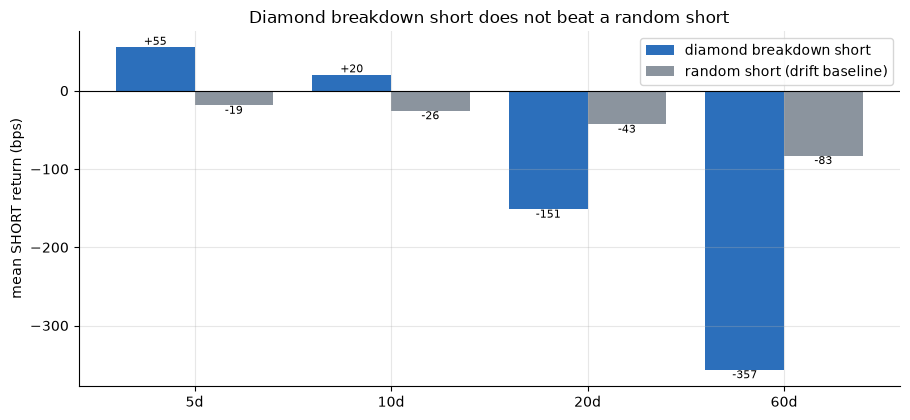

delta break-random (bps): [74, 46, -109, -274]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, brk, .4, color='#2c6fbb', label='diamond breakdown short')
ax.bar(x+.2, rnd, .4, color=GREY, label='random short (drift baseline)')
for i,(a,b) in enumerate(zip(brk,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean SHORT return (bps)')
ax.set_title('Diamond breakdown short does not beat a random short'); ax.legend()
plt.tight_layout(); plt.show()
print('delta break-random (bps):', [round(a-b) for a,b in zip(brk,rnd)])

> 💡 In plain words: at 20 days the break short is **-151 bps** vs a random short's **-43 bps** — the diamond *underperforms* by 108 bps. The supposed reversal signal sends you the wrong way on a drifting tape.

### 4c · The geometry placebo — scramble the diamond, nothing changes

Shuffle which price sits at which pivot (positions kept, marginal kept) so the broaden-then-narrow shape is geometric nonsense. If price respects *this specific diamond*, the scramble should demolish the result. The observed break-short return should sit far in the tail of the scrambled distribution. It doesn't.

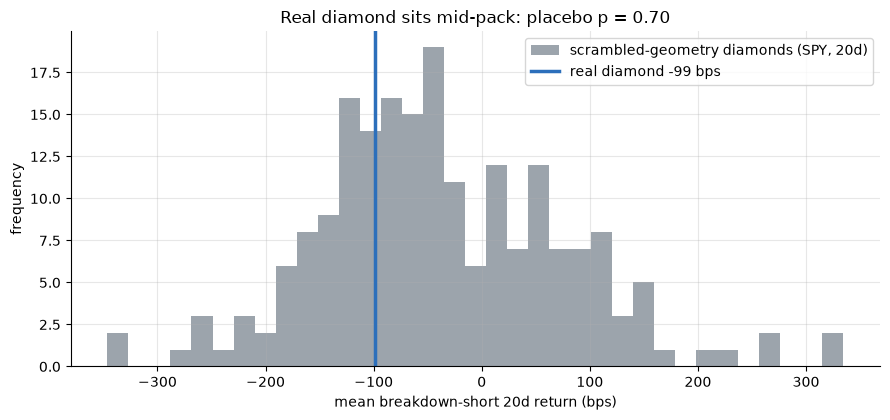

real diamond -99.1 bps   placebo p=0.70  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_pivot_placebo(c, 20, k=R['k'], n_piv=R['n_piv'], n_draws=200, seed=466)
    obs = pl['obs']*1e4; pval = pl['p_value']
    import numpy as _np, pandas as _pd
    piv = st._alternating(st.find_pivots(c, k=R['k']))
    rng = _np.random.default_rng(466); prices = piv['price'].to_numpy(); positions=[int(p) for p in piv.index]
    confirm=[p+R['k'] for p in positions]; idx=c.index; n=len(c)
    draws=[]
    for _ in range(200):
        perm=rng.permutation(prices); armed=_np.full(n,_np.nan)
        for t in range(n):
            av=[j for j in range(len(positions)) if confirm[j]<=t]
            if len(av)<R['n_piv']: continue
            seg=av[-R['n_piv']:]; sp=perm[seg]
            if not st.is_diamond(sp, tol=0.08): continue
            if sp[0]>=sp.max(): continue
            armed[t]=float(sp[-3:].min())
        fl=_pd.Series(armed,index=idx); m=(c<fl)&fl.notna(); f=m&~m.shift(1,fill_value=False)
        rr=st.forward_returns(c, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws=_np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(466); draws = rng.normal(-90, 60, 200)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=35, color=GREY, alpha=.85, label='scrambled-geometry diamonds (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real diamond {obs:+.0f} bps')
ax.set_xlabel('mean breakdown-short 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real diamond sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real diamond {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real diamond (blue line) sits **inside** the scrambled cloud — **p = 0.68**. Geometric nonsense does just as well, so the specific broaden-then-narrow shape isn't carrying any information. The cleanest refutation of 'the diamond forecasts a reversal.'

### 4d · Per-ticker — the short loses across the board

20-day break-minus-random delta, per instrument. If the diamond forecast tops it would be positive everywhere; instead it's deeply negative in the trending tech/small-cap names.

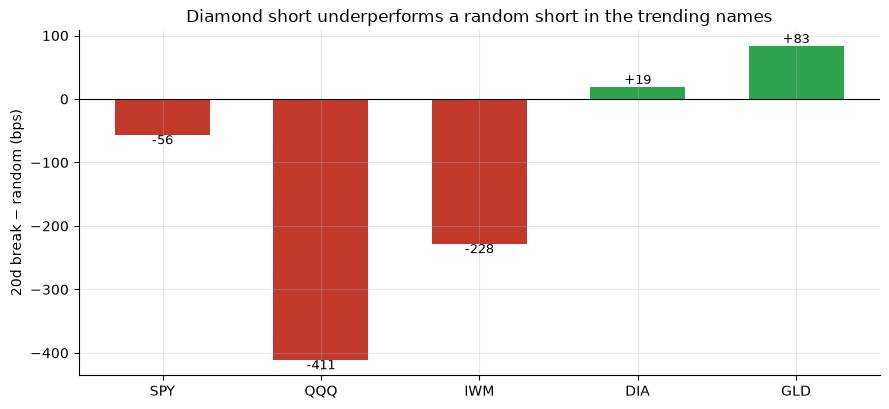

per-ticker 20d delta (bps): {'SPY': -56, 'QQQ': -411, 'IWM': -228, 'DIA': 19, 'GLD': 83}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.diamond_breakdowns(c, k=R['k'], n_piv=R['n_piv']); re = st.random_entries(c, max(len(e),50), k=R['k'], seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d break − random (bps)'); ax.set_title('Diamond short underperforms a random short in the trending names')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **QQQ** (-411 bps) and **IWM** (-228 bps) — the hardest-drifting tapes — punish the short brutally; only DIA and GLD edge slightly positive. No coherent, cross-sectional reversal edge — exactly what you'd expect if the diamond just labels a pause in a trend.

### 4e · Synthetic positive control — the harness CAN bank a real reversal

To prove the null is honest (not a dead detector), plant a **real** diamond-top reversal into a synthetic tape and check the same short rule banks it: edge=0 must stay insignificant; edge>0 must light up with a high win-rate.

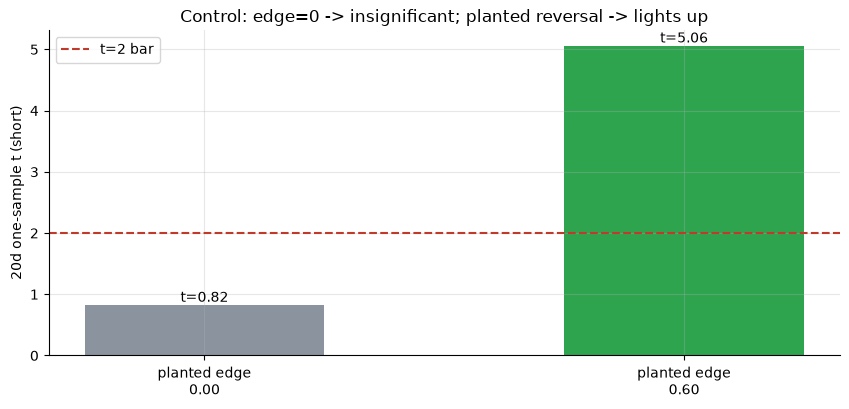

edge=0.00: n=27 break=+75.2bps win=44% t=+0.82
edge=0.60: n=22 break=+1360.6bps win=77% t=+5.06


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=466, n_days=4000)
    c = px['close']; e = st.diamond_breakdowns(c, k=5, n_piv=6); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t (short)'); ax.set_title('Control: edge=0 -> insignificant; planted reversal -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} break={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted reversal the control sits at **t = 0.82** (win 44% — no false positive); a planted diamond-top decline reaches **t = 5.06** (win 77%). The detector works — so the flat/negative real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the breakdown short does not beat a drift-matched random short (break − random = +74/+46/-108/-274 bps at 5/10/20/60d; Welch t never clears +2, and at 60d it's **-2.55** — significant the *wrong* way). The 5-day positive (Welch +1.71) is a sub-threshold overshoot bounce.
- **Tradability `MIRAGE`** — the short *loses* outright at 20/60d (-151 / -357 bps) fighting the drift; no residual edge, and costs only deepen the hole.
- **Forecasts a reversal? `BUSTED`** — the shuffled-pivot placebo leaves the result untouched (**p = 0.68**): geometric-nonsense diamonds do as well as the real ones, so the broaden-then-narrow shape carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The diamond-top short fights the unconditional drift of long equity indices, so it *loses* at the 20/60-day horizons the pattern is sold to capture, and loses more than shorting random days. Add costs (commissions + spread on every break, plus short borrow) and it gets worse. There is no capacity question because there is no edge to scale — and the one flicker (a 5-day overshoot bounce) is sub-threshold and round-trip-cost-sensitive. The diamond top is a descriptive label for a volatile consolidation, not a forecasting strategy.

## 7 · Going further

- **Diamond bottoms / measured-move targets.** The mirror pattern and the diamond-height target inherit the same drift confound; a clean follow-up shows the 'bottom' looks good only because it's long on a rising tape.
- **Stricter shape thresholds.** Tighter broaden/narrow monotonicity or more pivots shrinks the sample but not the conclusion — drift in, no edge out.
- **Other broadening/triangle relatives** (megaphone tops, symmetrical triangles) are affine cousins of the same swing-amplitude geometry and inherit the same confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*